# Cursos de Machine Learning en el Sector Bancario
## Modulo 10. `Aprobacion de Credito Automotriz`
                        Elaborado por: Naren Castellon

## `Dataset sintético para predicción de aprobación de crédito automotriz`

- application_id: ID único de solicitud
# - applicant_id: ID del solicitante (para repetidos)
# - ds: Fecha diaria de solicitud (timestamp)
# - applicant_age: Edad (18-70)
# - annual_income: Ingreso anual (USD)
# - employment_status: Estado laboral ('employed', 'self-employed', 'unemployed')
# - credit_score: Score crediticio (300-850)
# - debt_to_income_ratio: Ratio deuda/ingreso (0-0.6)
# - loan_amount_requested: Monto solicitado (USD, 10k-100k)
# - vehicle_value: Valor del automóvil (USD)
# - down_payment: Pago inicial (USD)
# - vehicle_type: Tipo de automóvil ('sedan', 'SUV', 'truck', 'luxury', 'electric')
# - vehicle_model: Modelo específico del automóvil (nuevo: e.g., 'Toyota Camry' para sedan, 'Ford F-150' para truck, etc.)
# - vehicle_year: Año del automóvil (2010-2024)
# - loan_term_months: Plazo del préstamo (meses, 36-84)
# - interest_rate: Tasa de interés (%, exógena)
# - marital_status: Estado civil ('single', 'married', 'divorced')
# - num_dependents: Número de dependientes (0-4)
# - residence_type: Tipo de residencia ('own', 'rent', 'family')
# - years_employed: Años empleado (0-40)
# - has_previous_auto_loan: Tiene préstamo automotriz previo (0/1)
# - previous_default: Default previo (0/1)
# - bank_account_balance: Saldo bancario (USD)
# - is_approved: Target (0/1, ~60-80% aprobación con lógica: buen score, bajo DTI, alto down payment, vehículo nuevo, etc.)

In [3]:
import pandas as pd  # Para manipulación de datos, creación de DataFrames y manejo de series temporales
import numpy as np   # Para generación de datos sintéticos numéricos, operaciones matemáticas y arrays
from datetime import datetime, timedelta  # Para generar fechas diarias secuenciales
import random  # Para selección aleatoria de categorías y variabilidad
import matplotlib.pyplot as plt  # Para visualizaciones básicas como gráficos de dispersión y matrices de confusión
import seaborn as sns  # Para gráficos avanzados en EDA, como heatmaps o distribuciones
from sklearn.model_selection import train_test_split  # Para dividir el dataset en train/test
from sklearn.preprocessing import LabelEncoder, StandardScaler  # Para codificar categóricas y escalar numéricas (importante para ML)
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc  # Métricas para evaluar modelo en clases desbalanceadas
from sklearn.ensemble import VotingClassifier, RandomForestClassifier  # Voting para ensemble, RandomForest como base
from sklearn.linear_model import LogisticRegression  # LogisticRegression como base
from xgboost import XGBClassifier  # XGBoost como base para diversidad en voting
import shap  # Para explicabilidad: SHAP values para entender contribuciones de features al modelo
import warnings
warnings.filterwarnings('ignore')  # Ignorar warnings menores para salida limpia

In [4]:
def generate_auto_credit_data(num_applicants=500, num_days=200):
    """
    Genera dataset sintético de solicitudes de crédito automotriz con frecuencia diaria.
    - num_applicants: Número de solicitantes únicos.
    - num_days: Días totales (total registros ~ num_applicants * num_days).
    Retorna DataFrame con variables realistas para predicción de aprobación.
    """
    np.random.seed(42)  # Reproducibilidad
    random.seed(42)
    
    data = []
    
    start_date = datetime(2023, 1, 1)  # Inicio para datos recientes
    
    # Mapeo de tipos de vehículo a modelos reales (agregado para realismo y detalle en predicciones)
    vehicle_models = {
        'sedan': ['Toyota Camry', 'Honda Civic', 'Hyundai Elantra', 'Ford Fusion', 'Nissan Altima'],
        'SUV': ['Toyota RAV4', 'Honda CR-V', 'Ford Explorer', 'Chevrolet Equinox', 'Jeep Grand Cherokee'],
        'truck': ['Ford F-150', 'Chevrolet Silverado', 'Ram 1500', 'Toyota Tacoma', 'GMC Sierra'],
        'luxury': ['Mercedes-Benz S-Class', 'BMW 7 Series', 'Audi A8', 'Lexus LS', 'Porsche Panamera'],
        'electric': ['Tesla Model 3', 'Tesla Model Y', 'Nissan Leaf', 'Chevrolet Bolt', 'Ford Mustang Mach-E']
    }
    
    for applicant in range(1, num_applicants + 1):
        applicant_id = f'Applicant_{applicant}'  # ID único
        dates = pd.date_range(start=start_date, periods=num_days, freq='D')  # Fechas diarias
        
        # Generar 0-2 solicitudes por día (para ~100k total)
        daily_apps = np.random.randint(0, 3, num_days)
        
        for i in range(num_days):
            for _ in range(daily_apps[i]):
                # ID solicitud único
                app_id = len(data) + 1
                
                # Edad: 18-70
                age = random.randint(18, 70)
                
                # Ingreso anual: Lognormal
                income = np.random.lognormal(10.8, 0.6)
                
                # Estado laboral
                employment = random.choice(['employed', 'self-employed', 'unemployed'])
                
                # Score crediticio: Correlacionado con edad/ingreso
                credit_score = 300 + (age / 70 * 200) + (income / 100000 * 350) + np.random.normal(0, 50)
                credit_score = np.clip(credit_score, 300, 850).astype(int)
                
                # DTI ratio: Bajo para altos ingresos
                dti = np.random.uniform(0.1, 0.4) if income > 60000 else np.random.uniform(0.3, 0.6)
                
                # Monto solicitado: 10k-100k
                loan_amount = random.uniform(10000, 100000)
                
                # Valor vehículo: Mayor que loan_amount
                vehicle_value = loan_amount * random.uniform(1.1, 1.5)
                
                # Pago inicial: 5-30% de vehicle_value
                down_payment = vehicle_value * random.uniform(0.05, 0.3)
                
                # Tipo vehículo
                vehicle_type = random.choice(['sedan', 'SUV', 'truck', 'luxury', 'electric'])
                
                # Modelo específico (nuevo: seleccionado del mapeo por tipo)
                vehicle_model = random.choice(vehicle_models[vehicle_type])
                
                # Año vehículo: 2010-2024
                vehicle_year = random.randint(2010, 2024)
                
                # Plazo: 36-84 meses
                loan_term = random.choice([36, 48, 60, 72, 84])
                
                # Tasa interés: 4-12%
                interest_rate = random.uniform(4, 12)
                
                # Estado civil
                marital = random.choice(['single', 'married', 'divorced'])
                
                # Dependientes
                dependents = random.randint(0, 4)
                
                # Residencia
                residence = random.choice(['own', 'rent', 'family'])
                
                # Años empleado
                years_employed = random.randint(0, 40)
                
                # Préstamo automotriz previo
                has_prev_auto = random.choice([0, 1])
                
                # Default previo
                prev_default = random.choice([0, 1]) if has_prev_auto else 0
                
                # Saldo bancario
                balance = np.random.normal(5000, 3000) + income * 0.1
                balance = max(balance, 0)
                
                # Aprobación: Lógica (alto score, bajo DTI, alto down payment, vehículo nuevo, no default, etc.)
                approve_prob = 0.6 + 0.25 * (credit_score > 700) - 0.2 * (dti > 0.4) - 0.3 * prev_default + 0.15 * (down_payment / vehicle_value > 0.2) + 0.1 * (vehicle_year > 2020) + 0.1 * (years_employed > 5)
                is_approved = random.choices([0, 1], weights=[1 - min(approve_prob, 0.99), min(approve_prob, 0.99)])[0]
                
                data.append({
                    'application_id': app_id,
                    'applicant_id': applicant_id,
                    'ds': dates[i],
                    'applicant_age': age,
                    'annual_income': round(income, 2),
                    'employment_status': employment,
                    'credit_score': credit_score,
                    'debt_to_income_ratio': round(dti, 2),
                    'loan_amount_requested': round(loan_amount, 2),
                    'vehicle_value': round(vehicle_value, 2),
                    'down_payment': round(down_payment, 2),
                    'vehicle_type': vehicle_type,
                    'vehicle_model': vehicle_model,  # Nueva variable: modelo específico
                    'vehicle_year': vehicle_year,
                    'loan_term_months': loan_term,
                    'interest_rate': round(interest_rate, 2),
                    'marital_status': marital,
                    'num_dependents': dependents,
                    'residence_type': residence,
                    'years_employed': years_employed,
                    'has_previous_auto_loan': has_prev_auto,
                    'previous_default': prev_default,
                    'bank_account_balance': round(balance, 2),
                    'is_approved': is_approved
                })
    
    df = pd.DataFrame(data)
    print(f"Dataset generado: {len(df)} registros con {len(df.columns)} variables (frecuencia diaria).")
    return df

# Generar dataset
auto_credit_df = generate_auto_credit_data(num_applicants=500, num_days=200)  # ~100k registros

# Guardar como CSV (opcional)
auto_credit_df.to_csv('auto_credit_data.csv', index=False)

Dataset generado: 99735 registros con 24 variables (frecuencia diaria).


In [5]:
auto_credit_df = pd.read_csv("auto_credit_data.csv")
auto_credit_df

,application_id,applicant_id,ds,applicant_age,annual_income,employment_status,credit_score,debt_to_income_ratio,loan_amount_requested,vehicle_value,...,loan_term_months,interest_rate,marital_status,num_dependents,residence_type,years_employed,has_previous_auto_loan,previous_default,bank_account_balance,is_approved
0,1,Applicant_1,2023-01-01,58,32937.17,employed,573,0.38,12250.97,14823.81,...,84,7.38,single,0,own,14,0,0,10747.34,1
1,2,Applicant_1,2023-01-01,63,26036.05,unemployed,533,0.60,73119.25,92701.16,...,48,9.59,married,2,own,13,1,0,8975.85,0
2,3,Applicant_1,2023-01-03,24,37606.81,self-employed,495,0.40,86274.49,115736.41,...,72,4.63,married,4,rent,36,0,0,13061.23,1
3,4,Applicant_1,2023-01-03,20,92918.33,unemployed,557,0.27,30510.84,37093.72,...,60,7.63,married,1,rent,22,0,0,18732.82,1
4,5,Applicant_1,2023-01-04,62,31021.13,unemployed,594,0.41,68323.18,91802.61,...,72,6.16,divorced,4,own,20,0,0,10285.61,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99730,99731,Applicant_500,2023-07-17,45,68141.72,unemployed,661,0.22,68003.54,96002.73,...,36,7.17,divorced,0,rent,35,0,0,16823.56,1
99731,99732,Applicant_500,2023-07-18,59,70210.82,self-employed,629,0.21,69867.27,104789.75,...,60,7.93,married,4,rent,37,0,0,11742.22,1
99732,99733,Applicant_500,2023-07-18,19,54322.24,self-employed,521,0.38,46324.11,59929.31,...,84,7.94,divorced,3,own,29,1,1,12958.83,1
99733,99734,Applicant_500,2023-07-19,40,25573.87,unemployed,515,0.33,65456.80,90677.16,...,60,6.20,divorced,2,rent,34,1,1,3985.40,0


In [6]:
# Paso 2: Análisis Exploratorio de Datos (EDA)
# Convertir ds a datetime
auto_credit_df['ds'] = pd.to_datetime(auto_credit_df['ds'])

In [7]:
# Resumen estadístico
print("\nEstadísticas descriptivas:")
print(auto_credit_df.describe())


Estadísticas descriptivas:
       application_id                             ds  applicant_age  \
count    99735.000000                          99735   99735.000000   
mean     49868.000000  2023-04-10 10:14:38.207249408      43.917812   
min          1.000000            2023-01-01 00:00:00      18.000000   
25%      24934.500000            2023-02-20 00:00:00      31.000000   
50%      49868.000000            2023-04-10 00:00:00      44.000000   
75%      74801.500000            2023-05-30 00:00:00      57.000000   
max      99735.000000            2023-07-19 00:00:00      70.000000   
std      28791.158886                            NaN      15.308734   

       annual_income  credit_score  debt_to_income_ratio  \
count   99735.000000  99735.000000          99735.000000   
mean    58860.650001    620.275119              0.375525   
min      3368.490000    300.000000              0.100000   
25%     32750.645000    532.000000              0.300000   
50%     49154.220000    607.0000

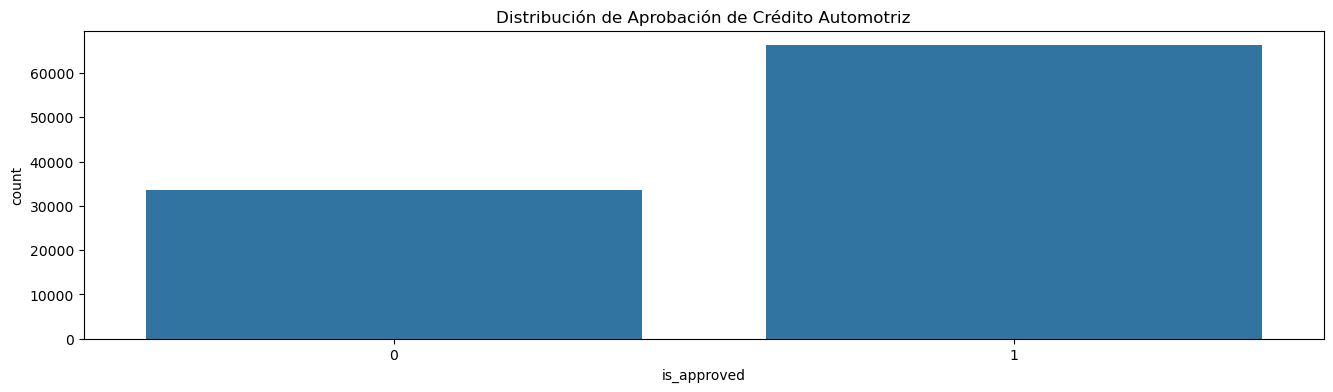

In [9]:
# Distribución de aprobación
plt.figure(figsize=(16, 4))
sns.countplot(x='is_approved', data=auto_credit_df)
plt.title('Distribución de Aprobación de Crédito Automotriz')
plt.show()

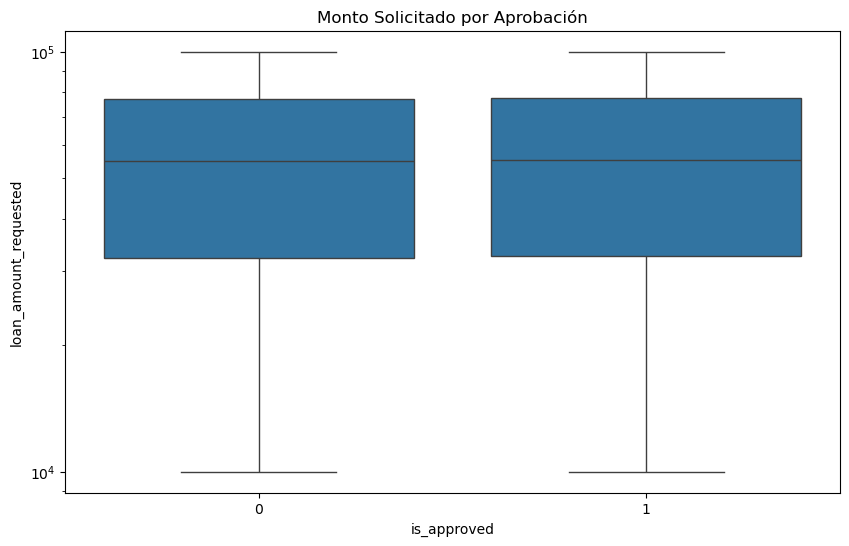

In [10]:
# Monto solicitado por aprobación
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_approved', y='loan_amount_requested', data=auto_credit_df)
plt.yscale('log')
plt.title('Monto Solicitado por Aprobación')
plt.show()

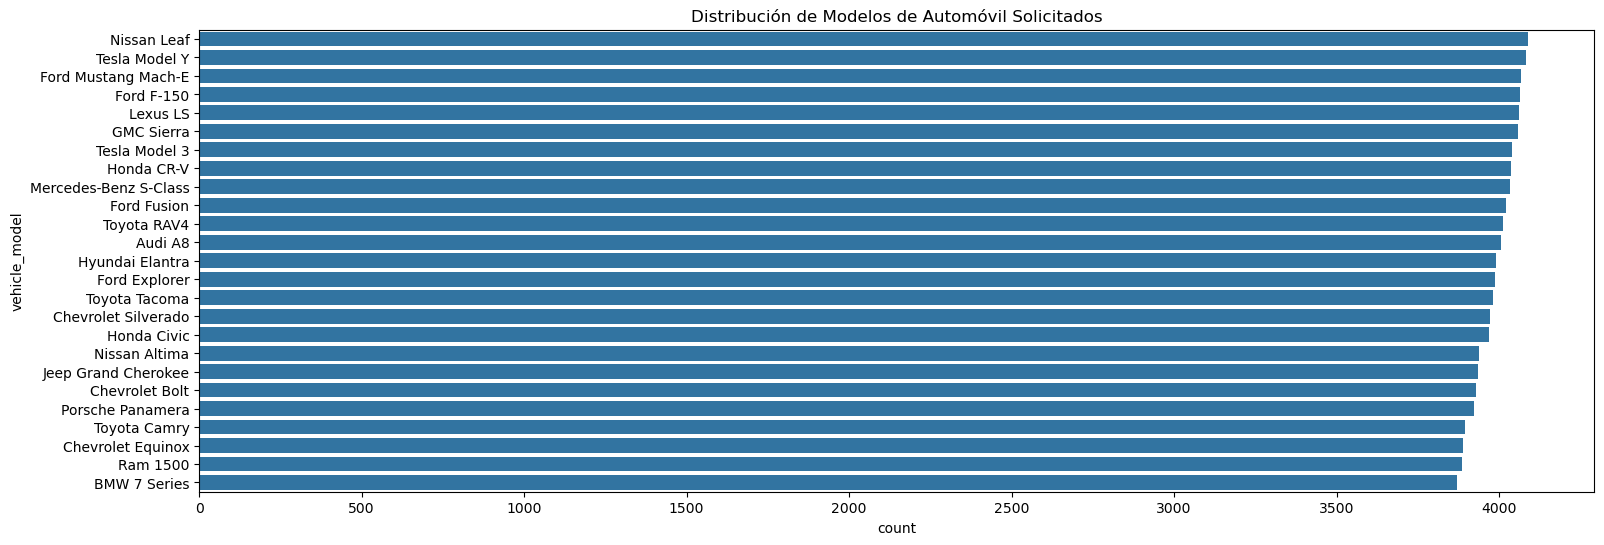

In [11]:
# Distribución de modelos de automóvil (nuevo EDA para variable agregada)
plt.figure(figsize=(18, 6))
sns.countplot(y='vehicle_model', data=auto_credit_df, order=auto_credit_df['vehicle_model'].value_counts().index)
plt.title('Distribución de Modelos de Automóvil Solicitados')
plt.show()

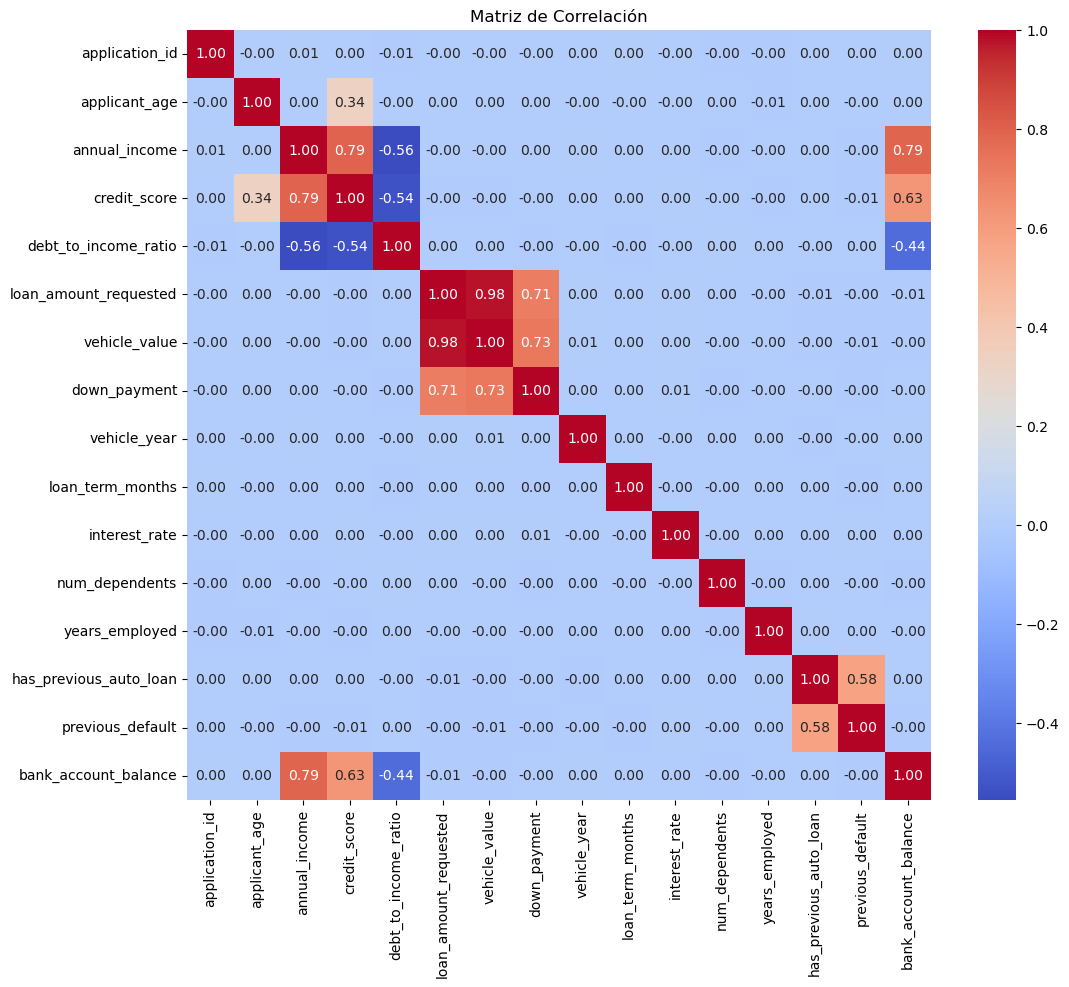

In [12]:
# Correlación numérica
numeric_cols = auto_credit_df.select_dtypes(include=[np.number]).columns.drop('is_approved')
corr_matrix = auto_credit_df[numeric_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

In [13]:
# Paso 3: Preprocesamiento para Voting
# Codificar categóricas (incluyendo 'vehicle_model' nueva)
cat_cols = ['employment_status', 'vehicle_type', 'vehicle_model', 'marital_status', 'residence_type']
le_dict = {col: LabelEncoder().fit(auto_credit_df[col]) for col in cat_cols}
for col in cat_cols:
    auto_credit_df[col] = le_dict[col].transform(auto_credit_df[col])

In [14]:
# Escalar numéricas
num_cols = ['applicant_age', 'annual_income', 'credit_score', 'debt_to_income_ratio', 'loan_amount_requested', 'vehicle_value', 'down_payment', 'interest_rate', 'num_dependents', 'years_employed', 'bank_account_balance', 'vehicle_year']
scaler = StandardScaler()
auto_credit_df[num_cols] = scaler.fit_transform(auto_credit_df[num_cols])

In [15]:
# Dividir train/test (estratificado por aprobación)
X = auto_credit_df.drop(columns=['application_id', 'applicant_id', 'ds', 'is_approved'])
y = auto_credit_df['is_approved']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [16]:
# Paso 4: Definir y Entrenar Voting
# Voting: Ensemble que combina predicciones de múltiples modelos base mediante voto mayoritario (hard) o promedio de probabilidades (soft)
# Bases: LogisticRegression (lineal), RandomForest (bagging), XGBoost (boosting) para diversidad
# Soft voting para usar probabilidades (mejor para clases desbalanceadas)
base_models = [
    ('lr', LogisticRegression(max_iter=1000, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=100, random_state=42))
]

voting_model = VotingClassifier(estimators=base_models, voting='soft', n_jobs=-1)  # Soft para probabilidades
voting_model

VotingClassifier(estimators=[('lr',
                              LogisticRegression(max_iter=1000,
                                                 random_state=42)),
                             ('rf', RandomForestClassifier(random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feat...
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=100, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                 n_jobs=-1, voting='soft')

In [17]:
voting_model.fit(X_train, y_train)

print("Modelo Voting entrenado.")

Modelo Voting entrenado.


In [18]:
# Paso 5: Evaluación del Modelo
y_pred = voting_model.predict(X_test)
y_prob = voting_model.predict_proba(X_test)[:, 1]

In [19]:
# Reporte y métricas
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))


Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.64      0.38      0.48      6694
           1       0.74      0.89      0.81     13253

    accuracy                           0.72     19947
   macro avg       0.69      0.64      0.64     19947
weighted avg       0.71      0.72      0.70     19947



In [20]:
roc_auc = roc_auc_score(y_test, y_prob)
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")

ROC-AUC: 0.7684
PR-AUC: 0.8733


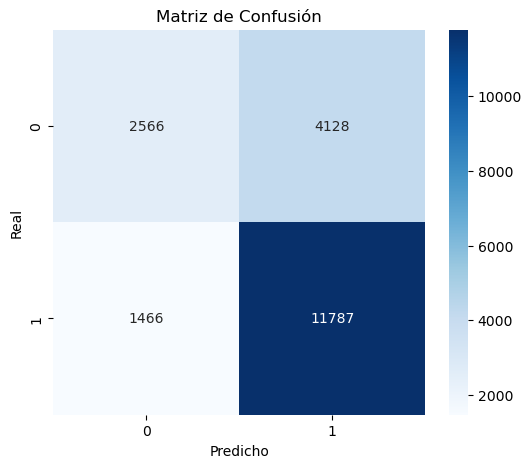

In [21]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()


Distribución de Riesgo en Test Set:
Riesgo
Riesgo Medio                     0.488394
Riesgo Bajo (Alta Prob Aprob)    0.451146
Riesgo Alto (Baja Prob Aprob)    0.060460
Name: proportion, dtype: float64


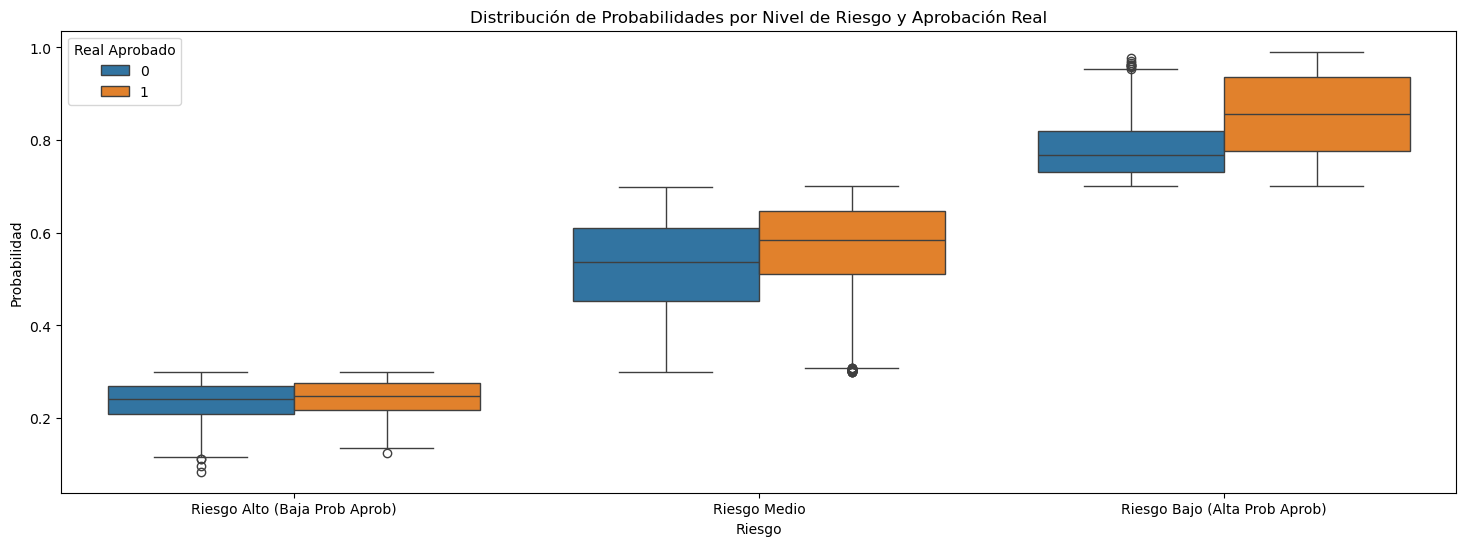

In [23]:
# Paso 6: Sección para Medir el Riesgo de Aprobación
# Riesgo: Basado en probabilidad (e.g., bajo <30%, medio 30-70%, alto >70%)
# Agregamos categorización de riesgo y visualización de distribución en test set
risk_levels = pd.cut(y_prob, bins=[0, 0.3, 0.7, 1.0], labels=['Riesgo Alto (Baja Prob Aprob)', 'Riesgo Medio', 'Riesgo Bajo (Alta Prob Aprob)'])
risk_df = pd.DataFrame({'Probabilidad': y_prob, 'Riesgo': risk_levels, 'Real Aprobado': y_test})
print("\nDistribución de Riesgo en Test Set:")
print(risk_df['Riesgo'].value_counts(normalize=True))

# Visualizar riesgo vs real
plt.figure(figsize=(18, 6))
sns.boxplot(x='Riesgo', y='Probabilidad', hue='Real Aprobado', data=risk_df)
plt.title('Distribución de Probabilidades por Nivel de Riesgo y Aprobación Real')
plt.show()

 14%|█▍        | 70/500 [01:48<11:07,  1.55s/it]Exception ignored in: <function ResourceTracker.__del__ at 0x1064eec00>
Traceback (most recent call last):
  File "/opt/miniconda3/envs/myenv/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/miniconda3/envs/myenv/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/miniconda3/envs/myenv/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x103a62c00>
Traceback (most recent call last):
  File "/opt/miniconda3/envs/myenv/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/miniconda3/envs/myenv/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/miniconda3/envs/myenv/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No 

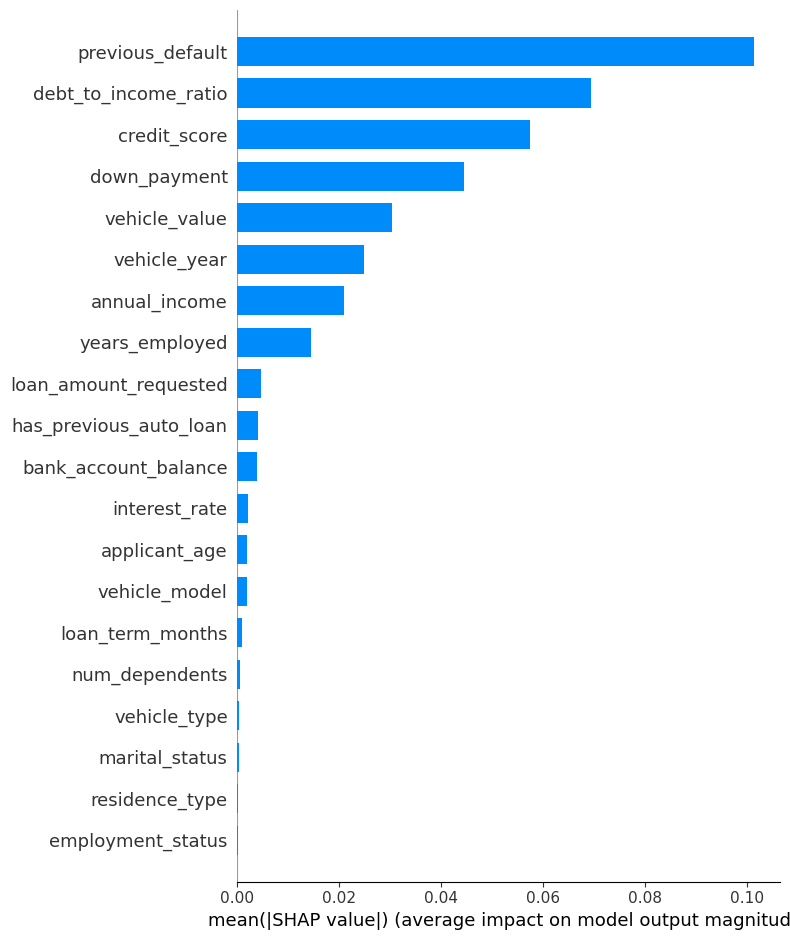

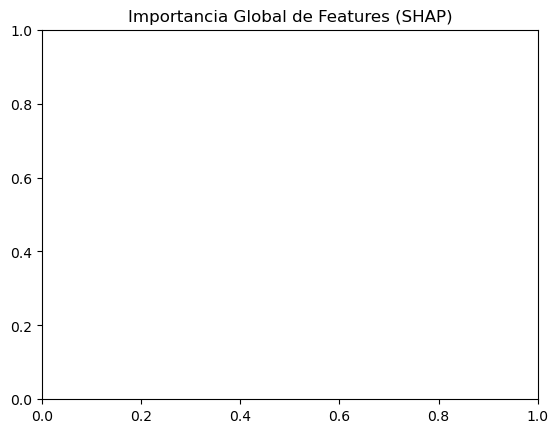

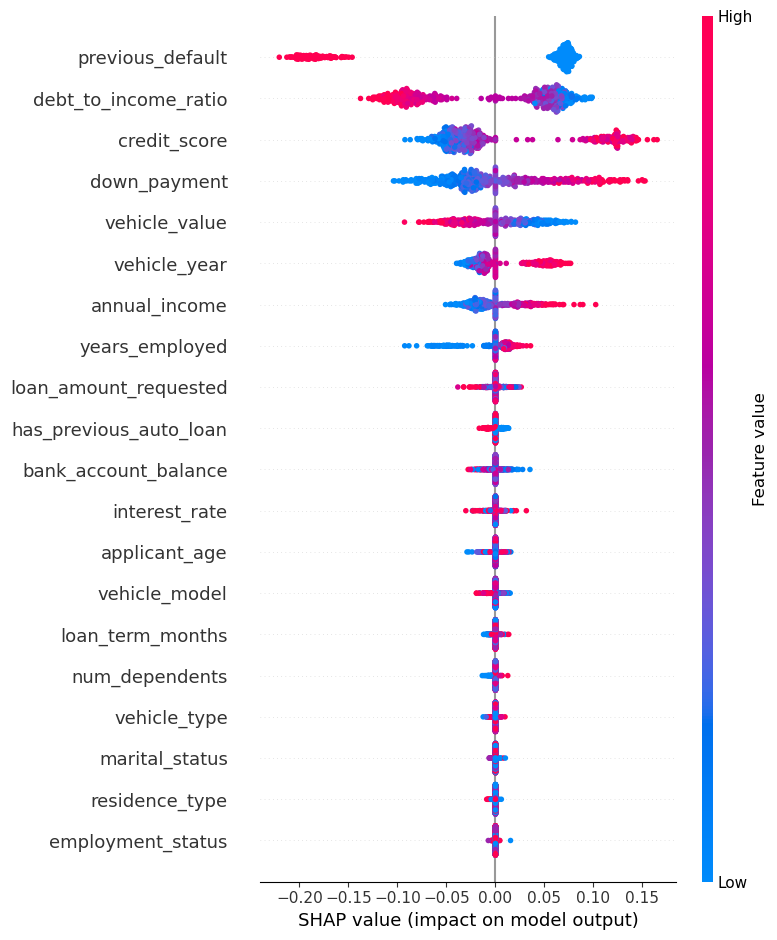

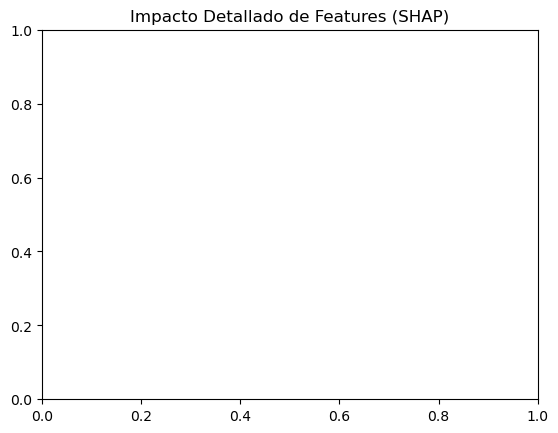

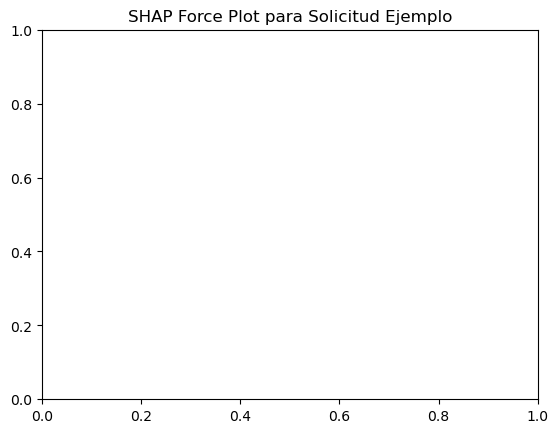


¡SHAP implementado correctamente! Ahora funciona con VotingClassifier.
- Corrección clave: lambda x: model.predict_proba(x)[:, 1] para KernelExplainer.
- Nota: KernelExplainer es lento; en producción, usa shap.Explainer con modelos tree-based o aproxima con uno de los bases.


In [25]:
# Paso 7: Implementar SHAP para Explicabilidad
# SHAP: Analiza contribuciones de features a predicciones (crucial en banca para transparencia)
# Voting no es directamente tree-based, pero usamos KernelExplainer (general pero slower)
# Para eficiencia, usamos KernelExplainer con muestra pequeña
# CORRECCIÓN: Usar lambda para extraer probabilidad de clase positiva ([:, 1])
explainer = shap.KernelExplainer(lambda x: voting_model.predict_proba(x)[:, 1], X_train.sample(100))  # Muestra pequeña para background

# SHAP values en muestra de test (para eficiencia)
X_test_sample = X_test.sample(500)
shap_values = explainer.shap_values(X_test_sample)

# Resumen global
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar")
plt.title('Importancia Global de Features (SHAP)')
plt.show()

# Resumen detallado
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample)
plt.title('Impacto Detallado de Features (SHAP)')
plt.show()

# Ejemplo individual (primera instancia)
shap.force_plot(explainer.expected_value, shap_values[0], X_test_sample.iloc[0])
plt.title('SHAP Force Plot para Solicitud Ejemplo')
plt.show()

print("\n¡SHAP implementado correctamente! Ahora funciona con VotingClassifier.")
print("- Corrección clave: lambda x: model.predict_proba(x)[:, 1] para KernelExplainer.")
print("- Nota: KernelExplainer es lento; en producción, usa shap.Explainer con modelos tree-based o aproxima con uno de los bases.")